In [1]:
!pip install keras-tuner opencv-python tensorflow

^C


In [2]:
from SoccerNet.Downloader import SoccerNetDownloader as SNdl
SOCCERNET_DIR='/content/SoccerNet'
PASSWORD='s0cc3rn3t'
downloader=SNdl(LocalDirectory=SOCCERNET_DIR)
downloader.downloadDataTask(task='mvfouls', split=['train','valid','test'], password=PASSWORD)

In [3]:
import zipfile
import os

def extract_zip(zip_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_dir)
    print(f"Done: {zip_path}")

base_path = "/content/SoccerNet/mvfouls"

drive_path = "/content/drive/MyDrive/Tugas/Deep Learning/Proyek/SoccerNet/mvfouls"

os.makedirs(base_path, exist_ok=True)
extract_zip(f"{base_path}/train.zip", f"{base_path}/train")
extract_zip(f"{base_path}/valid.zip", f"{base_path}/val")
extract_zip(f"{base_path}/test.zip", f"{base_path}/test")

Done: /content/SoccerNet/mvfouls/train.zip
Done: /content/SoccerNet/mvfouls/valid.zip
Done: /content/SoccerNet/mvfouls/test.zip


In [5]:
# import os
# print(os.listdir("/kaggle/input/datasets/rifqyw/soccernet"))

['valid', 'test', 'train']


In [8]:
# train_path = "/content/SoccerNet/mvfouls/train"
## Colab
# base_path = "/content/SoccerNet/mvfouls"
## Kaggle
base_path = "/kaggle/input/datasets/rifqyw/soccernet"

In [9]:
import os

files = []

for root, dirs, f in os.walk(base_path + "/train"):
    for file in f:
        files.append(os.path.join(root, file))

print("Jumlah file:", len(files))

for f in files[:100]:
    print(f)

Jumlah file: 6622
/kaggle/input/datasets/rifqyw/soccernet/train/annotations.json
/kaggle/input/datasets/rifqyw/soccernet/train/action_2073/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_2073/clip_1.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1327/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1327/clip_1.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1327/clip_2.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1516/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1516/clip_1.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_866/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_866/clip_1.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_458/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_458/clip_1.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1538/clip_0.mp4
/kaggle/input/datasets/rifqyw/soccernet/train/action_1538/clip_1.mp4
/kaggle/input/datasets/rif

In [10]:
video_files = [f for f in files if f.endswith(".mp4")]
other_files = [f for f in files if not f.endswith(".mp4")]

print("Jumlah video:", len(video_files))
print("Jumlah non-video:", len(other_files))

Jumlah video: 6621
Jumlah non-video: 1


In [13]:
import json

annotation_path = base_path + "/train/annotations.json"

with open(annotation_path, "r") as f:
    annotations = json.load(f)

print(type(annotations))
# print(annotations)S

<class 'dict'>


In [14]:
actions_dict = annotations["Actions"]

actions = [actions_dict[k] for k in sorted(actions_dict.keys(), key=int)]

In [15]:
import json

print(json.dumps(actions[0], indent=2))

{
  "UrlLocal": "england_epl\\2014-2015\\2015-02-21 - 18-00 Chelsea 1 - 1 Burnley",
  "Offence": "Offence",
  "Contact": "With contact",
  "Bodypart": "Upper body",
  "Upper body part": "Use of shoulder",
  "Action class": "Challenge",
  "Severity": "1.0",
  "Multiple fouls": "",
  "Try to play": "",
  "Touch ball": "",
  "Handball": "No handball",
  "Handball offence": "",
  "Clips": [
    {
      "Url": "Dataset/Train/action_0/clip_0",
      "Camera type": "Main camera center",
      "Timestamp": 1730826,
      "Replay speed": 1.0
    },
    {
      "Url": "Dataset/Train/action_0/clip_1",
      "Camera type": "Close-up player or field referee",
      "Timestamp": 1744173,
      "Replay speed": 1.8
    }
  ]
}


In [16]:
unique_contact = set()

for action in actions:
    unique_contact.add(action["Contact"])

unique_offence = set()

for action in actions:
    unique_offence.add(action["Offence"])

unique_action = set()

for action in actions:
    unique_action.add(action["Action class"])

unique_bodypart = set()

for action in actions:
    unique_bodypart.add(action["Bodypart"])

unique_upper = set()

for action in actions:
    unique_upper.add(action["Upper body part"])

print("contact", unique_contact)
print("offence", unique_offence)
print("action", unique_action)
print("bodypart", unique_bodypart)
print("upper body", unique_upper)

contact {'With contact', 'Without contact'}
offence {'Offence', '', 'Between', 'No offence'}
action {'', 'Dont know', 'Pushing', 'Elbowing', 'Challenge', 'Dive', 'Standing tackling', 'Tackling', 'High leg', 'Holding'}
bodypart {'', 'Under body', 'Upper body'}
upper body {'', 'Use of shoulders', 'Use of arms', 'Use of shoulder'}


In [19]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    return HTML(f"""
    <video width=600 controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

show_video(base_path + "/test/action_10/clip_1.mp4")

In [20]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    return HTML(f"""
    <video width=600 controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

show_video(base_path + "/test/action_10/clip_0.mp4")

In [53]:
import os
import re

def normalize(x):
    if not isinstance(x, str):
        return ""
    return re.sub(r"\s+", " ", x.strip().lower())

def normalize_path(path):
    path = path.replace("Dataset/", "")
    path = path.replace("\\", "/")

    path = path.replace("Train/", "train/")
    ## Colab
    # path = path.replace("Valid/", "val/")
    ## Kaggle
    path = path.replace("Valid/", "valid/")
    path = path.replace("Test/", "test/")

    return path

In [54]:
def build_dataset(actions_dict, base_path):
    dataset = []

    allowed_actions = {"tackling", "challenge"}

    for action_id, action in actions_dict.items():

        action_class = normalize(action.get("Action class", ""))
        if action_class not in allowed_actions:
            continue

        label_raw = normalize(action.get("Offence", ""))
        if label_raw not in ["offence", "no offence"]:
            continue

        y = 1 if label_raw == "offence" else 0

        clips = action.get("Clips", [])
        if len(clips) == 0:
            continue

        dataset.append((action_id, y))

    return dataset

In [55]:
import json
from collections import Counter

with open(base_path + "/train/annotations.json", "r") as f:
    annotations_train = json.load(f)

with open(base_path + "/valid/annotations.json", "r") as f:
    annotations_val = json.load(f)

with open(base_path + "/test/annotations.json", "r") as f:
    annotations_test = json.load(f)

train_actions = annotations_train["Actions"]
val_actions   = annotations_val["Actions"]
test_actions  = annotations_test["Actions"]

train_data = build_dataset(train_actions, base_path)
val_data   = build_dataset(val_actions, base_path)
test_data  = build_dataset(test_actions, base_path)

print("TRAIN:", Counter([y for _, y in train_data]))
print("VAL:", Counter([y for _, y in val_data]))
print("TEST:", Counter([y for _, y in test_data]))

TRAIN: Counter({1: 650, 0: 153})
VAL: Counter({1: 97, 0: 16})
TEST: Counter({1: 79, 0: 16})


In [58]:
import cv2
import numpy as np
def extract_frames(video_path, n_frames=16):

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    segments = np.linspace(0, total, n_frames+1, dtype=int)

    frames = []

    for i in range(n_frames):

        start, end = segments[i], segments[i+1]
        frame_idx = np.random.randint(start, max(start+1, end))

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.resize(frame, (224, 224))
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return np.zeros((16,224,224,3), np.float32)

    return np.array(frames, np.float32)

In [343]:
import numpy as np
import os
import cv2

def compute_motion(frames):
    flows = []

    prev = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)

    for i in range(1, len(frames)):
        curr = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev, curr,
            None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )

        flows.append(np.mean(flow))

        prev = curr

    flows = np.array(flows + [0.0])

    return flows.reshape(-1, 1)  # (16,1)

In [344]:
import tensorflow as tf
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False

/tmp/ipykernel_58/2843476388.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [345]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def extract_features(frames, base_model):
    frames = preprocess_input(frames.astype(np.float32))
    return base_model.predict(frames, verbose=0)

In [373]:
import numpy as np
import os
def build_features_multi(action, base_path, base_model):

    clip_feats = [
        np.zeros((16, 1280), np.float32),  # clip_0
        np.zeros((16, 1280), np.float32)   # clip_1
    ]

    for clip in action.get("Clips", []):

        url = clip.get("Url", "")
        path = normalize_path(url + ".mp4")
        full_path = os.path.join(base_path, path)

        if not os.path.exists(full_path):
            continue

        frames = extract_frames(full_path)

        frame_feat = extract_features(frames, base_model)      # (16, 1280)
        motion_feat = compute_motion(frames)                    # (16, 1)
        combined = np.concatenate([frame_feat, motion_feat], axis=1)  # (16, 1281)

        if "clip_0" in url:
            clip_feats[0] = combined
        elif "clip_1" in url:
            clip_feats[1] = combined

    return np.stack(clip_feats, axis=0) 

In [370]:
os.remove("/kaggle/working/test_cache.pkl")
os.remove("/kaggle/working/train_cache.pkl")
os.remove("/kaggle/working/val_cache.pkl")

In [374]:
import pickle
import os

def build_cache(dataset, actions, base_path, base_model, cache_file):

    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            return pickle.load(f)

    cache = {}
    
    for i, (action_id, label) in enumerate(dataset):

        if i % 10 == 0:
            print(f"{i}/{len(dataset)}")

        action = actions[str(action_id)]

        feats = build_features_multi(action, base_path, base_model)
        # print(np.mean(feats))
        # print(np.std(feats))
        
        if feats is None:
            continue

        cache[action_id] = (feats, label)
        
    with open(cache_file, "wb") as f:
        pickle.dump(cache, f)

    return cache

In [375]:
train_features = build_cache(
    dataset=train_data,
    actions=train_actions,
    base_path=base_path,
    base_model=base_model,
    cache_file="train_cache.pkl"
)

val_features = build_cache(
    dataset=val_data,
    actions=val_actions,
    base_path=base_path,
    base_model=base_model,
    cache_file="val_cache.pkl"
)

test_features = build_cache(
    dataset=test_data,
    actions=test_actions,
    base_path=base_path,
    base_model=base_model,
    cache_file="test_cache.pkl"
)

0/803
10/803
20/803
30/803
40/803
50/803
60/803
70/803
80/803
90/803
100/803
110/803
120/803
130/803
140/803
150/803
160/803
170/803
180/803
190/803
200/803
210/803
220/803
230/803
240/803
250/803
260/803
270/803
280/803
290/803
300/803
310/803
320/803
330/803
340/803
350/803
360/803
370/803
380/803
390/803
400/803
410/803
420/803
430/803
440/803
450/803
460/803
470/803
480/803
490/803
500/803
510/803
520/803
530/803
540/803
550/803
560/803
570/803
580/803
590/803
600/803
610/803
620/803
630/803
640/803
650/803
660/803
670/803
680/803
690/803
700/803
710/803
720/803
730/803
740/803
750/803
760/803
770/803
780/803
790/803
800/803
0/113
10/113
20/113
30/113
40/113
50/113
60/113
70/113
80/113
90/113
100/113
110/113
0/95
10/95
20/95
30/95
40/95
50/95
60/95
70/95
80/95
90/95


In [376]:
class FastVideoGenerator(tf.keras.utils.Sequence):

    def __init__(self, dataset, cache, batch_size=16, augment=False):

        self.dataset = dataset
        self.cache = cache
        self.batch_size = batch_size
        self.augment = augment
        self.indices = np.arange(len(dataset))

    def __len__(self):
        return int(np.ceil(len(self.dataset) / self.batch_size))

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

    def __getitem__(self, idx):

        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        X, y = [], []

        for i in batch_idx:

            action_id, label = self.dataset[i]

            if action_id not in self.cache:
                continue

            feats, _ = self.cache[action_id]

            if self.augment:
                noise = np.random.normal(0, 0.01, feats.shape)
                feats = np.clip(feats + noise, 0, None)

            X.append(feats)
            y.append(label)
        if len(X) == 0:
            return self.__getitem__((idx + 1) % self.__len__())

        return (
            np.array(X, dtype=np.float32),
            np.array(y, dtype=np.int32)
        )

In [414]:
train_gen_fast = FastVideoGenerator(
    dataset=train_data,
    cache=train_features,
    batch_size=16,
    augment=True
)

val_gen_fast = FastVideoGenerator(
    dataset=val_data,
    cache=val_features,
    batch_size=16,
    augment=False
)

test_gen_fast = FastVideoGenerator(
    dataset=test_data,
    cache=test_features,
    batch_size=16,
    augment=False
)


print(f"Train batches per epoch: {len(train_gen_fast)}")
print(f"Val batches per epoch: {len(val_gen_fast)}")


Train batches per epoch: 51
Val batches per epoch: 8


In [435]:
inp = tf.keras.Input(shape=(2, 16, 1281))

x = layers.BatchNormalization()(inp)
clip0 = x[:, 0]
clip1 = x[:, 1]

# LSTM for each clip
lstm0 = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(clip0)
lstm1 = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(clip1)

x = layers.Concatenate()([lstm0, lstm1])  # (256,)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inp, out)

In [436]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = np.array([y for _, y in train_data])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=labels
)

class_weight_dict = dict(zip([0,1], class_weights))
mean = np.mean(list(class_weight_dict.values()))
class_weight_dict = {k: v/mean for k,v in class_weight_dict.items()}

In [437]:
import shutil

shutil.rmtree("/kaggle/working/checkpoint")

In [438]:
import tensorflow as tf
model.compile(
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    ),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [439]:
import tensorflow as tf

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="checkpoint/model_epoch_{epoch:02d}.keras",
    save_weights_only=False,
    save_best_only=False,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=3,
    restore_best_weights=True,
    mode='max'
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1,
    mode='max'
)

In [440]:
history = model.fit(
    train_gen_fast,
    validation_data=val_gen_fast,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[checkpoint_cb, early_stop, reduce_lr]
)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6640 - auc: 0.4948 - loss: 0.4817 - precision: 0.8411 - recall: 0.7357
Epoch 1: saving model to checkpoint/model_epoch_01.keras

Epoch 1: finished saving model to checkpoint/model_epoch_01.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5828 - auc: 0.5304 - loss: 0.4885 - precision: 0.8247 - recall: 0.6154 - val_accuracy: 0.7611 - val_auc: 0.5474 - val_loss: 0.5645 - val_precision: 0.8431 - val_recall: 0.8866 - learning_rate: 0.0010
Epoch 2/10
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7938 - auc: 0.8723 - loss: 0.3086 - precision: 0.9396 - recall: 0.7980
Epoch 2: saving model to checkpoint/model_epoch_02.keras

Epoch 2: finished saving model to checkpoint/model_epoch_02.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8331 - auc: 0.8800 - loss: 0.2947 - precision: 0.9373 - recall: 0.8508 - val_accuracy: 0.7788 - val_auc: 0.6050 - val_loss: 0.5337 - val_precision: 0.8913 - val_recall: 0.8

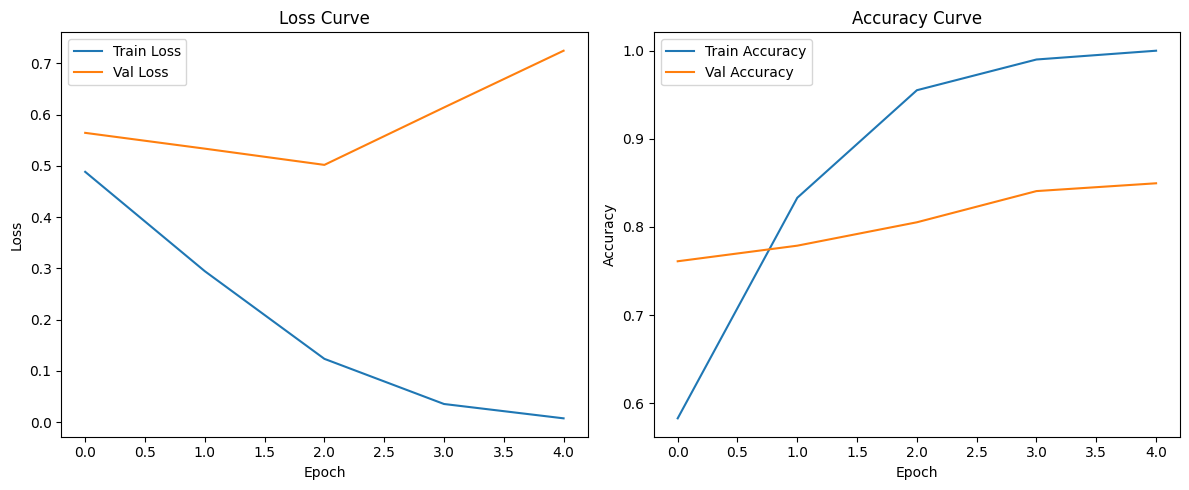

In [441]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.tight_layout()
plt.show()

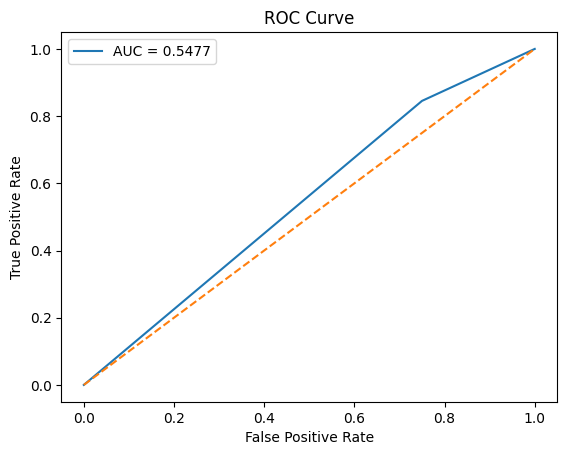

In [442]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [443]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ambil ground truth & prediksi
y_true = []
y_pred = []

for X, y in val_gen_fast:
    preds = model.predict(X, verbose=0)

    y_true.extend(y)
    y_pred.extend((preds > 0.5).astype(int).reshape(-1))

In [445]:
from sklearn.metrics import classification_report

y_pred_label = (y_pred > 0.5).astype(int)

print(classification_report(y_true, y_pred_label, target_names=["no offence", "offence"]))

              precision    recall  f1-score   support

  no offence       0.29      0.38      0.32        16
     offence       0.89      0.85      0.87        97

    accuracy                           0.78       113
   macro avg       0.59      0.61      0.60       113
weighted avg       0.81      0.78      0.79       113



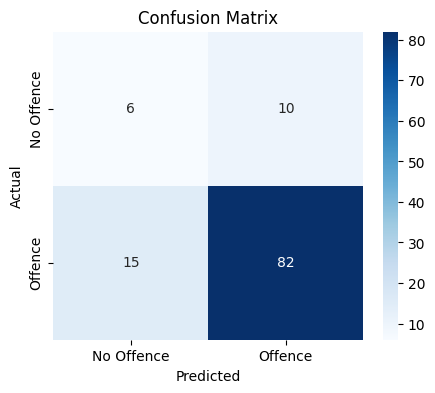

[[ 6 10]
 [15 82]]


In [444]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Offence", "Offence"],
            yticklabels=["No Offence", "Offence"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(cm)

## Hyper Parameter Tuning

In [446]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers

def build_model(hp):

    inp = tf.keras.Input(shape=(2, 16, 1281))

    x = layers.BatchNormalization()(inp)

    clip0 = x[:, 0]
    clip1 = x[:, 1]
\
    lstm_units = hp.Choice("lstm_units", [64, 128, 256])

    lstm_layer = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False)
    )

    l0 = lstm_layer(clip0)
    l1 = lstm_layer(clip1)

    x = layers.Concatenate()([l0, l1])

    dense_units = hp.Choice("dense_units", [64, 128, 256])

    x = layers.Dense(dense_units, activation='relu')(x)

    dropout = hp.Float("dropout", 0.2, 0.6, step=0.1)

    x = layers.Dropout(dropout)(x)

    x = layers.Dense(dense_units // 2, activation='relu')(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    lr = hp.Choice("lr", [1e-2, 1e-3, 5e-4, 1e-4])

    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy")
        ]
    )

    return model

In [447]:
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [448]:
tuner = kt.Hyperband(
    build_model,
    objective="val_auc",
    max_epochs=15,
    factor=3,
    directory="tuning_dir",
    project_name="tackling_classification"
)

Reloading Tuner from tuning_dir/tackling_classification/tuner0.json


In [449]:
tuner.search(
    train_gen_fast,
    validation_data=val_gen_fast,
    epochs=10,
    callbacks=[stop_early]
)

In [450]:
best_model = tuner.get_best_models(num_models=1)[0]

best_hp = tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

{'lstm_units': 64, 'dense_units': 128, 'dropout': 0.2, 'lr': 0.01, 'tuner/epochs': 15, 'tuner/initial_epoch': 5, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0023'}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [451]:
model = build_model(best_hp)
history = model.fit(
    train_gen_fast,
    validation_data=val_gen_fast,
    epochs=30,
    class_weight=None,
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7995 - auc: 0.4257 - loss: 0.5498 - precision: 0.8083 - recall: 0.9862 - val_accuracy: 0.8584 - val_auc: 0.3644 - val_loss: 0.4538 - val_precision: 0.8584 - val_recall: 1.0000
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8095 - auc: 0.6535 - loss: 0.4671 - precision: 0.8110 - recall: 0.9969 - val_accuracy: 0.8584 - val_auc: 0.4327 - val_loss: 0.4486 - val_precision: 0.8584 - val_recall: 1.0000
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8306 - auc: 0.8150 - loss: 0.3850 - precision: 0.8427 - recall: 0.9723 - val_accuracy: 0.8496 - val_auc: 0.5229 - val_loss: 0.4440 - val_precision: 0.8571 - val_recall: 0.9897
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8543 - auc: 0.8434 - loss: 0.3587 - precision: 0.8676 - recall: 0.9677 - val_accuracy: 0.8407 - val_auc: 0.4868 - val_loss: 0.4704 - val_precision: 0.8624 - val_recall: 0.9691
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━

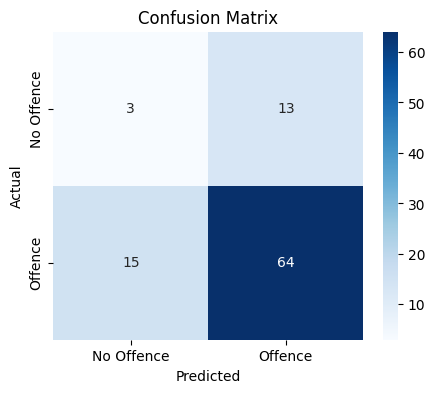

[[ 3 13]
 [15 64]]


In [459]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Offence", "Offence"],
            yticklabels=["No Offence", "Offence"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(cm)

In [465]:
model.save("model_offence.keras")

In [466]:
import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model("model_offence.keras")

In [472]:
import numpy as np
import os

def extract_video_feature(video_path, action, base_model, base_path):

    feats = build_features_multi(action, base_path, base_model)

    return feats  # (2,16,1280)

In [473]:
import tensorflow as tf

def predict_video(video_path, action, model, base_model, base_path):

    feats = extract_video_feature(video_path, action, base_model, base_path)

    x = np.expand_dims(feats, axis=0)  # (1,2,16,1280)

    score = model.predict(x, verbose=0)[0][0]
    label = 1 if score >= 0.5 else 0

    return score, label

In [474]:
def show_annotation(action):

    return {
        "offence": action.get("Offence"),
        "action_class": action.get("Action class"),
        "contact": action.get("Contact"),
        "bodypart": action.get("Bodypart"),
        "severity": action.get("Severity"),
    }

In [476]:
def run_single_test(action_id, actions, model, base_model, base_path):

    action = actions[str(action_id)]

    # ambil salah satu clip (misalnya clip_0)
    video_path = action["Clips"][0]["Url"] + ".mp4"
    video_path = normalize_path(video_path)
    full_path = os.path.join(base_path, video_path)

    # prediksi
    score, pred_label = predict_video(full_path, action, model, base_model, base_path)

    # annotation asli
    ann = show_annotation(action)

    print("="*60)
    print("VIDEO:", full_path)
    print("TRUE LABEL:", ann["offence"])
    print("PRED SCORE:", score)
    print("PRED LABEL:", "offence" if pred_label==1 else "no offence")
    print("ACTION CLASS:", ann["action_class"])
    print("CONTACT:", ann["contact"])
    print("SEVERITY:", ann["severity"])
    print("="*60)

In [485]:
run_single_test(
    action_id="150",
    actions=annotations_test["Actions"],
    model=model,
    base_model=base_model,
    base_path=base_path
)

VIDEO: /kaggle/input/datasets/rifqyw/soccernet/test/action_150/clip_0.mp4
TRUE LABEL: Offence
PRED SCORE: 0.8175603
PRED LABEL: offence
ACTION CLASS: Elbowing
CONTACT: With contact
SEVERITY: 1.0
